<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Prueba_Kolmogorov_Smirnov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pureba Kolmogorov-Smirnov**

Es un método utilizado para *determinar si una muestra* de datos dados *sigue una distribución específica o no*

In [48]:
#Importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


La hipótesis es: $$H_0: X_n - U(0,1) $$

In [49]:
df=pd.read_excel("datos_prueba_promedios.xlsx") #Aquí cargamos el archivo de excel con los datos
datos=df['Datos'].dropna().values   #Lo pasamos a un arreglo, la columna con el nombre 'Datos' es donde estan todos los números

<img src="https://lh3.googleusercontent.com/drive-storage/AJQWtBNWfm1JG5AHa-e-6tg9Hn9tcQwkRCfz56lXraaom1pyCTeMO3nRl8NJxABPZUiCMnVwkonhpzN2OKF7z0TRokzUwKCva9rZz_rcHuacJC90FpSi8w=w1852-h870?auditContext=forDisplay" width="400" height="400">

In [50]:
n = len(datos)
datos_ordenados=np.sort(datos) #Ordenamos los datos del más chico al más grande

#Funciones que vamos a utilizar
i=np.arange(1, n+1)
F_mas=i / n  # (x_i +)= i/n
F_menos=(i-1) / n #(x_i -)= i-1/n
x_i=datos_ordenados

# D+ y D- que ocupamos para imprimirlos en el ciclo
D_mas1= abs(F_mas-x_i)
D_menos1= abs(x_i-F_menos)

#Calculamos D+, D-, D
D_mas=np.abs(F_mas-x_i) #Primero calculamos el valor absoluto de (i/n - x_i)
D_menos=np.max(x_i - F_menos) #Luego calculamos el máximo
D_mas2=np.max(D_mas) #Calculo de |x_i - i-1/n|
D = max(D_mas2, D_menos)

In [51]:
#Imprimimos los resultados
print("   x_i    |    D_i+     |    D_i-  ")
print("------------------------------------")

for j in range(n):
    print(f"{x_i[j]:.5f} | "f"{D_mas1[j]:.5f} | "f"{D_menos1[j]:.5f}")


alpha=0.05
d_critico=1.36 / np.sqrt(n)

print("Valor crítico d =",round(d_critico,6))

if D<d_critico:
    print("Se acepta H0 (datos uniformes(0,1))")
else:
    print("Se rechaza H0")


   x_i    |    D_i+     |    D_i-  
------------------------------------
0.00121 | 0.00879 | 0.00121
0.03185 | 0.01185 | 0.02185
0.03272 | 0.00272 | 0.01272
0.05010 | 0.01010 | 0.02010
0.05230 | 0.00230 | 0.01230
0.05475 | 0.00525 | 0.00475
0.07281 | 0.00281 | 0.01281
0.08128 | 0.00128 | 0.01128
0.09133 | 0.00133 | 0.01133
0.09264 | 0.00736 | 0.00264
0.10699 | 0.00301 | 0.00699
0.10850 | 0.01150 | 0.00150
0.11537 | 0.01463 | 0.00463
0.12079 | 0.01921 | 0.00921
0.14151 | 0.00849 | 0.00151
0.15506 | 0.00494 | 0.00506
0.17028 | 0.00028 | 0.01028
0.18284 | 0.00284 | 0.01284
0.19147 | 0.00147 | 0.01147
0.19904 | 0.00096 | 0.00904
0.19962 | 0.01038 | 0.00038
0.20852 | 0.01148 | 0.00148
0.21631 | 0.01369 | 0.00369
0.22287 | 0.01713 | 0.00713
0.22724 | 0.02276 | 0.01276
0.23949 | 0.02051 | 0.01051
0.24000 | 0.03000 | 0.02000
0.26593 | 0.01407 | 0.00407
0.27738 | 0.01262 | 0.00262
0.28269 | 0.01731 | 0.00731
0.29453 | 0.01547 | 0.00547
0.29931 | 0.02069 | 0.01069
0.30861 | 0.02139 | 0.01139
0.3

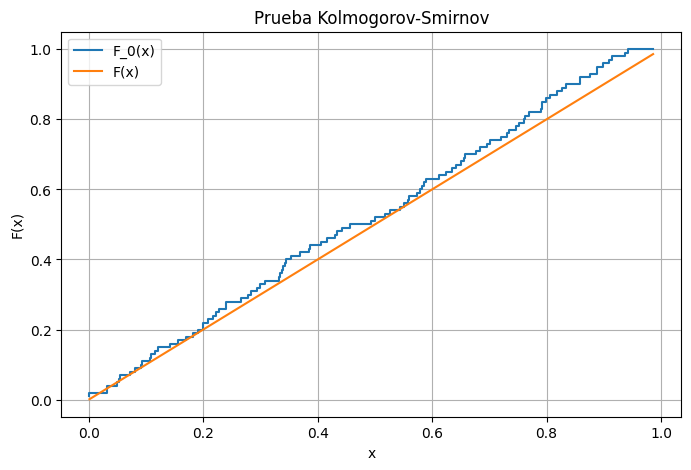

In [52]:
#Graficamos las dos funciones
plt.figure(figsize=(8,5))

# Función obtenida
plt.step(datos_ordenados, F_mas, label="F_0(x)")
# Función de los datos
plt.plot(datos_ordenados, x_i, label="F(x)")

plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Prueba Kolmogorov-Smirnov")
plt.legend()
plt.grid(True)
plt.show()